In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score,precision_score,recall_score

In [5]:
df = pd.read_csv('candy-data.csv')
df.drop(columns=['competitorname'],inplace=True)
df.head()


,chocolate,fruity,caramel,peanutyalmondy,nougat,crispedricewafer,hard,bar,pluribus,sugarpercent,pricepercent,winpercent
0,1,0,1,0,0,1,0,1,0,0.732,0.860,66.971725
1,1,0,0,0,1,0,0,1,0,0.604,0.511,67.602936
2,0,0,0,0,0,0,0,0,0,0.011,0.116,32.261086
3,0,0,0,0,0,0,0,0,0,0.011,0.511,46.116505
4,0,1,0,0,0,0,0,0,0,0.906,0.511,52.341465


In [6]:
trainingSet, testSet = train_test_split(df,test_size=0.2,random_state=7)


In [ ]:
train_df = trainingSet
test_df = testSet
print(train_df,test_df)


    chocolate  fruity  caramel  peanutyalmondy  nougat  crispedricewafer  \
49          0       1        0               0       0                 0   
62          1       0        0               0       0                 0   
30          0       1        0               0       0                 0   
22          1       0        0               0       0                 0   
27          1       0        0               0       0                 0   
..        ...     ...      ...             ...     ...               ...   
23          1       0        0               0       0                 1   
67          0       1        0               0       0                 0   
25          1       0        0               0       0                 0   
68          0       1        0               0       0                 0   
47          1       0        0               1       0                 0   

    hard  bar  pluribus  sugarpercent  pricepercent  winpercent  
49     1    0        

In [8]:
df.columns.to_list()

['chocolate',
 'fruity',
 'caramel',
 'peanutyalmondy',
 'nougat',
 'crispedricewafer',
 'hard',
 'bar',
 'pluribus',
 'sugarpercent',
 'pricepercent',
 'winpercent']

In [11]:
X_train = train_df[ ['fruity',
 'caramel',
 'peanutyalmondy',
 'nougat',
 'crispedricewafer',
 'hard',
 'bar',
 'pluribus',
 'sugarpercent',
 'pricepercent',
 'winpercent']]
Y_train = train_df['chocolate']
X_test = test_df[[ 'fruity',
 'caramel',
 'peanutyalmondy',
 'nougat',
 'crispedricewafer',
 'hard',
 'bar',
 'pluribus',
 'sugarpercent',
 'pricepercent',
 'winpercent']]
Y_test = test_df['chocolate']
print(X_train.shape,Y_train.shape,X_test.shape,Y_test.shape)

(68, 11) (68,) (17, 11) (17,)


In [12]:
Y_train.value_counts()

chocolate
0    35
1    33
Name: count, dtype: int64

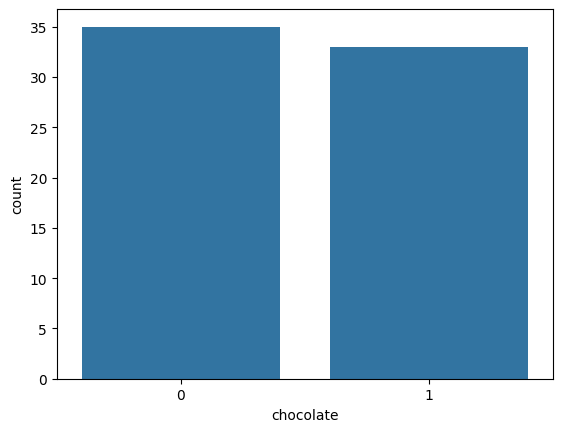

In [18]:
sns.countplot(x=Y_train)
plt.show()

In [17]:
logreg = LogisticRegression()
logreg.fit(X_train,Y_train)
Y_pred = logreg.predict(X_test)
print(Y_pred)

[0 0 0 0 0 1 0 0 1 0 0 1 0 0 0 1 0]


In [19]:
cnf_matrix = confusion_matrix(Y_test,Y_pred)
print(cnf_matrix)

[[13  0]
 [ 0  4]]


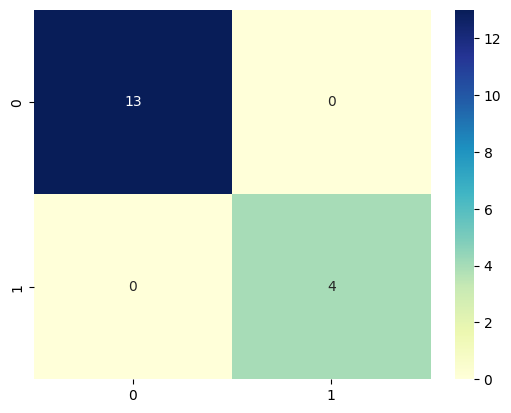

In [27]:

fig,ax = plt.subplots()
sns.heatmap(pd.DataFrame(cnf_matrix),annot=True,cmap = 'YlGnBu',fmt='g')
plt.show()


Text(0.5, 1.0, 'Confusion Matrix Heatmap')

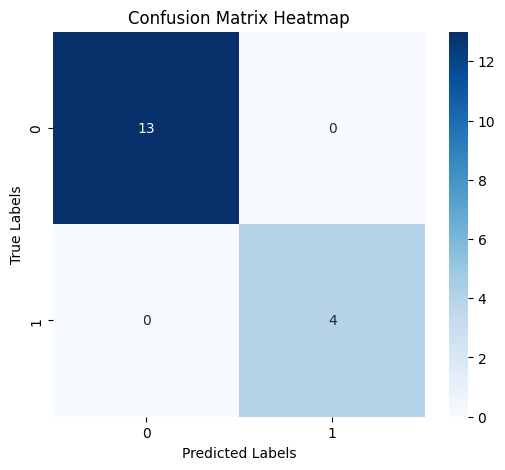

In [30]:

cm = confusion_matrix(Y_test, Y_pred)


plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', xticklabels=['0', '1'], yticklabels=['0', '1'])

plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix Heatmap')


In [32]:
print('Accuracy',accuracy_score(Y_test,Y_pred))
print('Precision',precision_score(Y_test,Y_pred))
print('Recall',recall_score(Y_test,Y_pred))

Accuracy 1.0
Precision 1.0
Recall 1.0
